In [ ]:
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("TMDB")
    .config("spark.sql.parquet.mergeSchema", "false")
    .config("spark.sql.parquet.enableVectorizedReader", "true")
    .getOrCreate()
)
df = spark.read.parquet("/Spark_tmdb/data")

sns.set_theme(style="whitegrid")

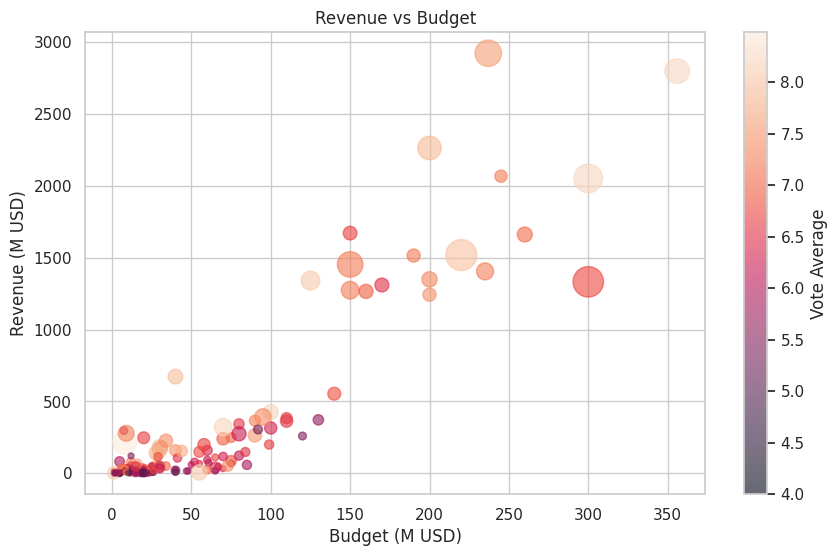

In [15]:
# ----------------------------
# INTERNAL HELPERS
# ----------------------------
def _to_pandas(df, cols, limit=5000):
    return df.select(*cols).dropna().limit(limit).toPandas()


# ----------------------------
# 1. Revenue vs Budget
# ----------------------------
def plot_revenue_vs_budget(df):
    pdf = _to_pandas(
        df,
        ["budget_musd", "revenue_musd", "popularity", "vote_average"]
    )

    plt.figure(figsize=(10, 6))

    plt.scatter(
        pdf["budget_musd"],
        pdf["revenue_musd"],
        c=pdf["vote_average"],
        s=pdf["popularity"] * 10,
        alpha=0.6
    )

    plt.colorbar(label="Vote Average")
    plt.xlabel("Budget (M USD)")
    plt.ylabel("Revenue (M USD)")
    plt.title("Revenue vs Budget")
    plt.show()

plot_revenue_vs_budget(df)

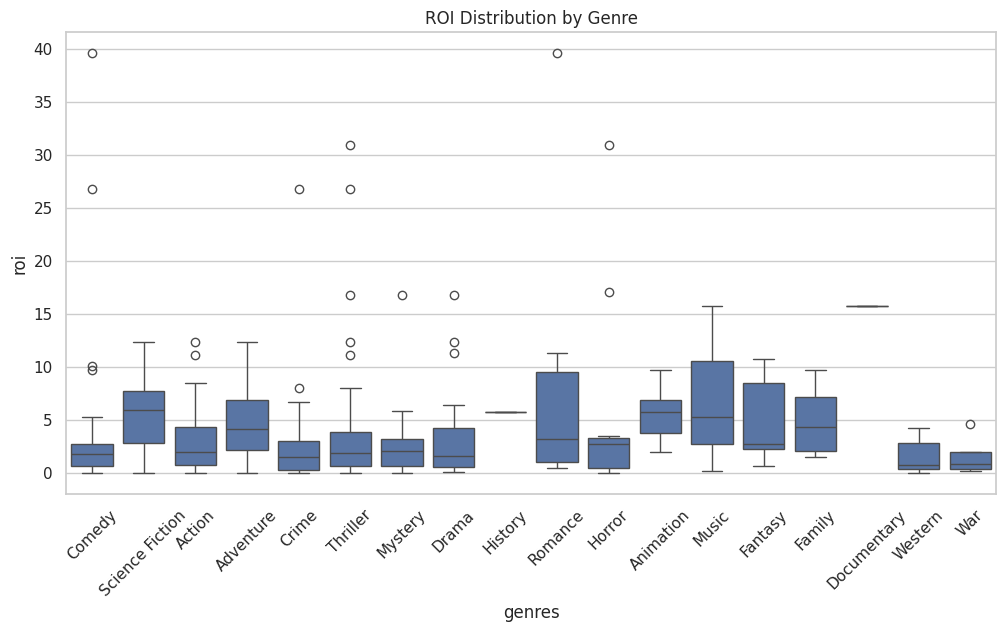

In [19]:
# ----------------------------
# 2. ROI Distribution by Genre
# ----------------------------
from pyspark.sql import functions as F

def plot_roi_by_genre(df):
    df2 = (
        df.select("genres", "budget_musd", "revenue_musd")
          .withColumn("roi", F.col("revenue_musd") / F.col("budget_musd"))
          .withColumn("genres", F.explode(F.split("genres", "\\|")))
          .select("genres", "roi")
          .dropna()
    )

    pdf = df2.toPandas()

    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=pdf, x="genres", y="roi")
    plt.xticks(rotation=45)
    plt.title("ROI Distribution by Genre")
    plt.show()
plot_roi_by_genre(df)


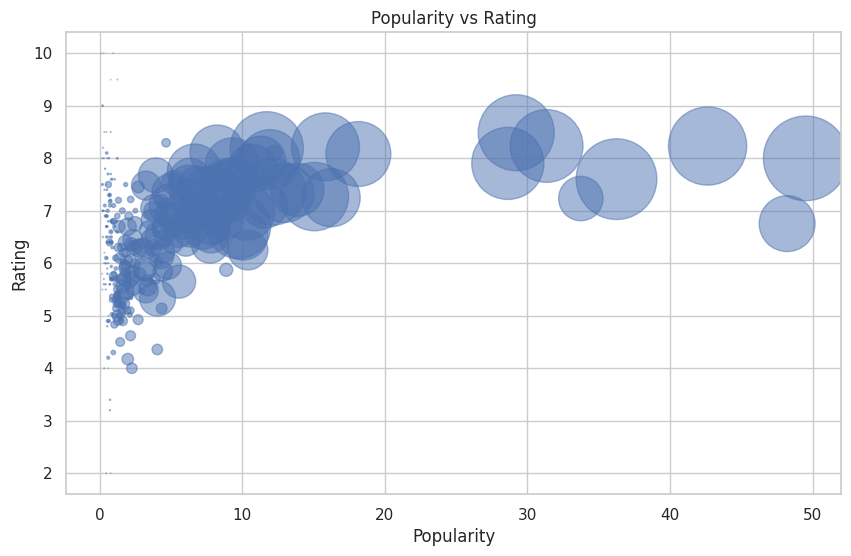

In [20]:
# ----------------------------
# 3. Popularity vs Rating
# ----------------------------
def plot_popularity_vs_rating(df):
    pdf = _to_pandas(
        df,
        ["popularity", "vote_average", "vote_count"]
    )

    plt.figure(figsize=(10, 6))

    plt.scatter(
        pdf["popularity"],
        pdf["vote_average"],
        s=pdf["vote_count"] / 10,
        alpha=0.5
    )

    plt.xlabel("Popularity")
    plt.ylabel("Rating")
    plt.title("Popularity vs Rating")
    plt.show()

plot_popularity_vs_rating(df)

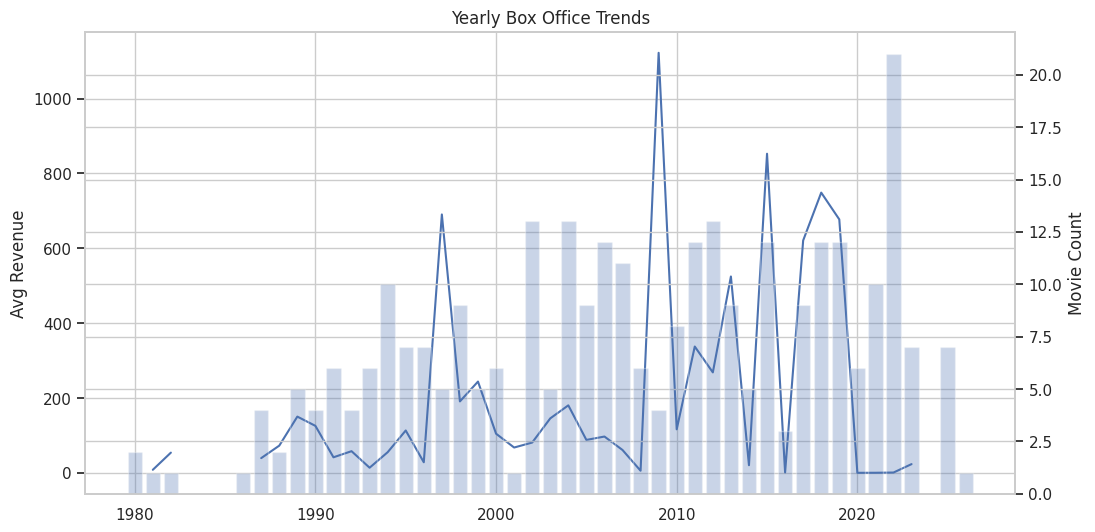

In [21]:
# ----------------------------
# 4. Yearly Box Office Trends
# ----------------------------
def plot_yearly_trends(df):
    pdf = (
        df.withColumn("year", F.year("release_date"))
          .groupBy("year")
          .agg(
              F.mean("revenue_musd").alias("avg_revenue"),
              F.count("*").alias("movie_count")
          )
          .orderBy("year")
          .toPandas()
    )

    fig, ax1 = plt.subplots(figsize=(12, 6))

    ax1.plot(pdf["year"], pdf["avg_revenue"])
    ax1.set_ylabel("Avg Revenue")

    ax2 = ax1.twinx()
    ax2.bar(pdf["year"], pdf["movie_count"], alpha=0.3)
    ax2.set_ylabel("Movie Count")

    plt.title("Yearly Box Office Trends")
    plt.show()
plot_yearly_trends(df)

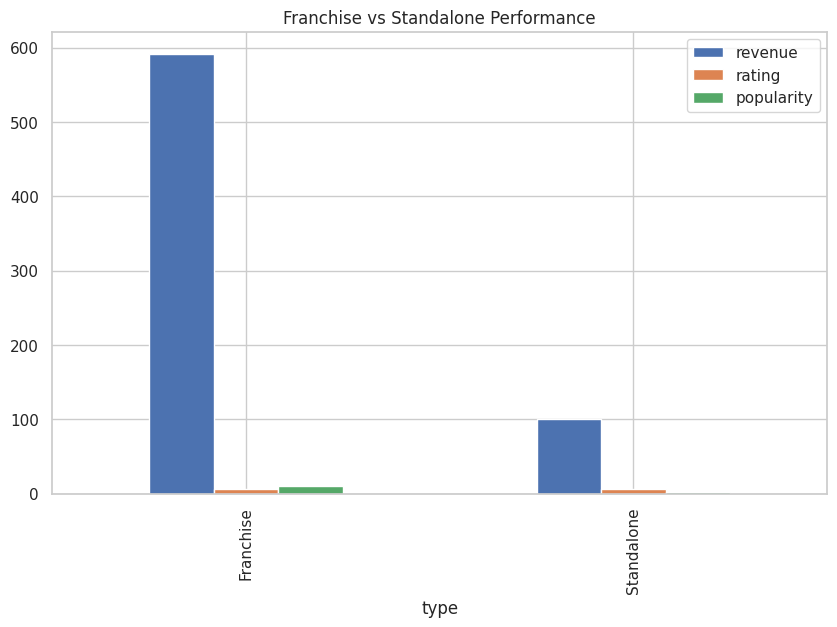

In [22]:
# ----------------------------
# 5. Franchise vs Standalone
# ----------------------------
def plot_franchise_vs_standalone(df):
    pdf = (
        df.withColumn(
            "type",
            F.when(F.col("belongs_to_collection").isNotNull(), "Franchise")
             .otherwise("Standalone")
        )
        .groupBy("type")
        .agg(
            F.mean("revenue_musd").alias("revenue"),
            F.mean("vote_average").alias("rating"),
            F.mean("popularity").alias("popularity")
        )
        .toPandas()
    )

    pdf.set_index("type")[["revenue", "rating", "popularity"]].plot(
        kind="bar",
        figsize=(10, 6)
    )

    plt.title("Franchise vs Standalone Performance")
    plt.show()
plot_franchise_vs_standalone(df)